In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick
from flax import nnx


ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

In [3]:

@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4 = jax.random.split(rng, 5)
    bvals = jax.random.choice(rng0, jnp.array(list(range(0, 2100, 100))), shape=(100,))
    bvals = jnp.sort(bvals)
    bvecs = jax.random.normal(rng3, shape=(100, 3))
    bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)
    theta = jax.random.normal(rng1, shape=(Ball2Stick.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.6, shape=(3,))
    #model_mask = jnp.array([True, True, True])
    ball_stick = Ball2Stick.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(bvals, bvecs)
    x_o = x_o + jax.random.normal(rng4, shape=x_o.shape) * 0.01
    return model_mask, theta, x_o, bvals, bvecs


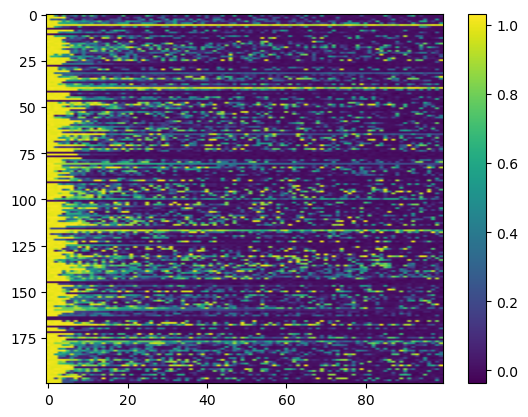

In [4]:
masks, theta, x_o, bvals, bvecs = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto')
plt.colorbar()

In [5]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig

cfg = DMRIInferenceModelConfig(Ball2Stick)

model = DMRIInferenceModel(cfg, nnx.Rngs(0))

params_encoder = nnx.state(model.encoder)
params_model_decoder = nnx.state(model.model_decoder)
params_inference_decoder = nnx.state(model.inference_decoder)

params = (params_encoder, params_model_decoder, params_inference_decoder)


In [6]:
nnx.display(model)

In [7]:
import optax


optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.adamw(5e-4))

opt_state = optimizer.init(params)


In [7]:

def loss_fn(params, data, rng):
    components, thetas,  xs, bvals, bvecs = data

    return model._loss(params[0], params[1], params[2], components, thetas, bvals, bvecs, xs, rng)


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [12]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [56]:
key = jax.random.PRNGKey(3)
for i in range(200):
    key, subkey1 = jax.random.split(key, 2)
    masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(subkey1, 2**18))
    l = 0
    for j in range(1000):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (256,), 0, 2**18)
        masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = masks[idx], thetas[idx], x_os[idx], bvals[idx], bevecs[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/10000)

0.26748556
0.2668356
0.2657072
0.26591757
0.26558354
0.26434174
0.26435554
0.26300633
0.2638774
0.2625318
0.26262075
0.2618499
0.2613109
0.26062772
0.26119095
0.26071978
0.26025108
0.2600546
0.25951388
0.25914136
0.2591476
0.25863495
0.25785485
0.25895056
0.2571574
0.2574537
0.25681633
0.257464
0.25682122
0.25627962
0.25652045
0.25636902
0.25578108
0.25603598
0.25509563
0.2552046
0.2561731
0.25534016
0.25450274
0.25394207
0.25479865
0.25424346
0.25418767
0.2540796
0.2536417
0.25430146
0.25457007
0.25305998
0.2530881
0.25322717
0.25226805
0.25264826
0.25266993
0.2514273
0.25166416
0.2521763
0.25209844
0.2517213
0.25159827
0.25226593
0.2509777
0.2512927
0.25100523
0.25033563
0.25097415
0.24994574
0.25015357
0.25055525
0.24957743
0.250677
0.24953416
0.2497931
0.24980329
0.24910706
0.24926034
0.24881558
0.24910878
0.24874306
0.24841076
0.24925363
0.24846722
0.24844684
0.24799943
0.24824318
0.2478725
0.24772123
0.24810502
0.2476889
0.24769479
0.24713695
0.24682416
0.24767987
0.24709952
0.24

In [57]:
nnx.update(model.encoder, params[0])
nnx.update(model.model_decoder, params[1])
nnx.update(model.inference_decoder, params[2])

In [71]:
# import pickle

# with open('params.pkl', 'wb') as f:
#     pickle.dump(params, f)

In [8]:
import pickle
with open('params.pkl', 'rb') as f:
    params = pickle.load(f)
    nnx.update(model.encoder, params[0])
    nnx.update(model.model_decoder, params[1])
    nnx.update(model.inference_decoder, params[2])

In [16]:
idx = 5

In [17]:
masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [18]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 128), bvals[idx], bevecs[idx], x_os[idx])

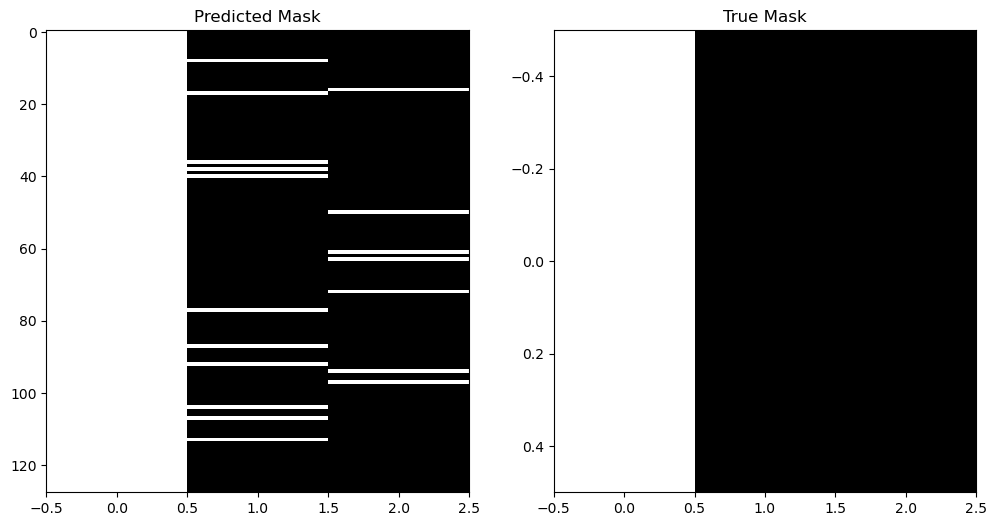

In [19]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')

plt.show()

In [20]:
from functools import partial

In [21]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=32, max_noise=20), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 1024), bvals[idx], bevecs[idx], x_os[idx],masks[idx])

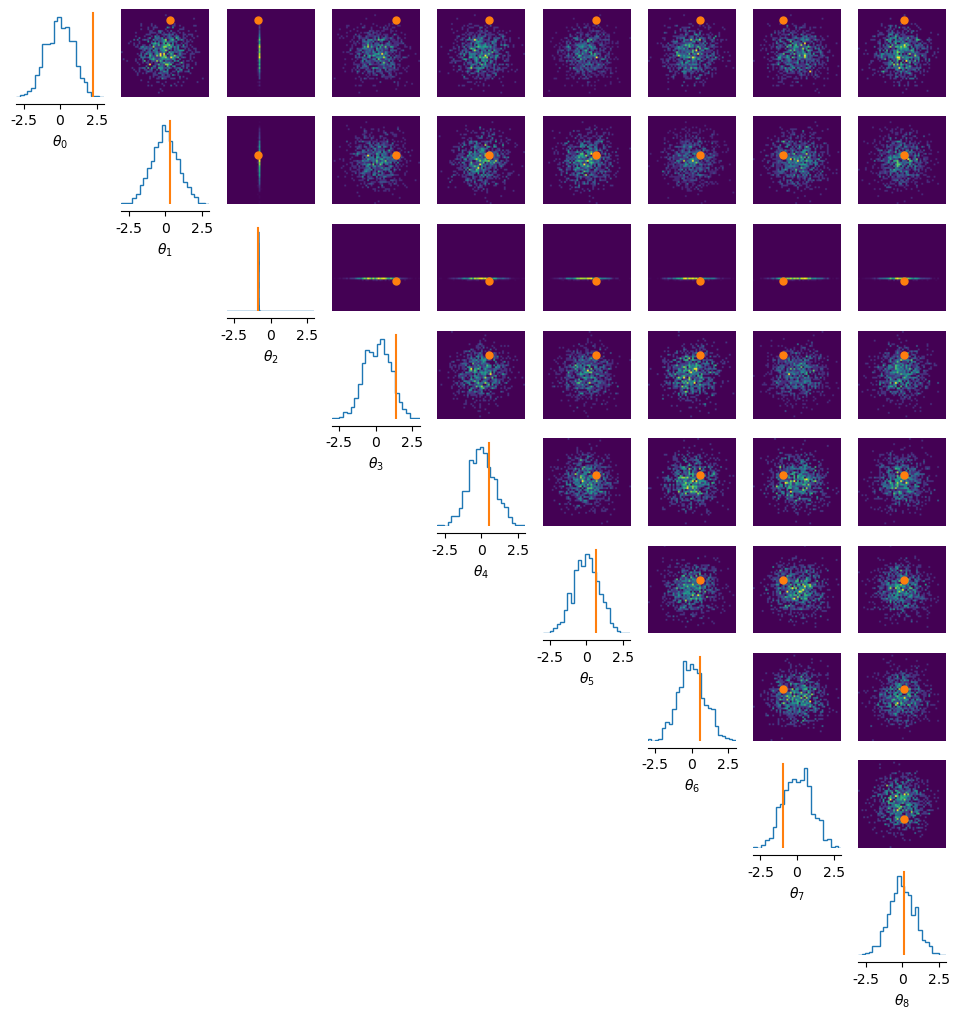

: 

In [ ]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*9], labels=[f'$\\theta_{i}$' for i in range(9)], figsize=(12, 12))

In [130]:
def posterior_pred(theta):
    return Ball2Stick.from_theta(theta, model_mask=masks[idx]).signal(bvals[idx], bevecs[idx])

posterior_preds = jax.vmap(posterior_pred)(thetas_post)

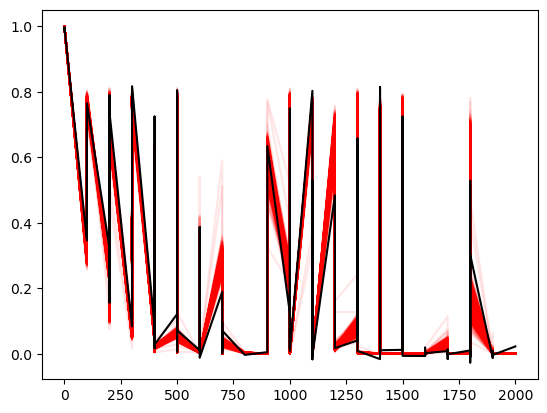

In [131]:
_ = plt.plot(bvals[idx], posterior_preds.T, label="posterior pred", color="red", alpha=0.1)
_ = plt.plot(bvals[idx], x_os[idx], label="data", color="black")